# Store Sales Forecasting: Steps 0 to 2

Kaggle *Store Sales: Time Series Forecasting* (Corporación Favorita, Ecuador).

| Step | What |
|---|---|
| 0 | Load data, check libraries, hold out the last 16 days, RMSLE function |
| 1 | Explore: plots, weekly pattern, decomposition, ACF |
| 2 | Baseline forecasts: the score every model must beat |

Runs locally or on AIDP. On AIDP, change `DATA_DIR` to wherever the CSVs are.

## Step 0: Setup

In [1]:
import importlib

# Which forecasting libraries are available here? On AIDP this tells you what to pip install.
for lib in ["pandas", "numpy", "matplotlib", "statsmodels", "statsforecast", "prophet", "lightgbm", "sklearn"]:
    try:
        print(f"{lib:12} {getattr(importlib.import_module(lib), '__version__', 'ok')}")
    except ImportError:
        print(f"{lib:12} MISSING")

pandas       2.3.3
numpy        2.4.6


matplotlib   3.11.2
statsmodels  0.15.0


statsforecast 2.1.1


Importing plotly failed. Interactive plots will not work.


prophet      1.5.0


lightgbm     4.7.0
sklearn      1.9.1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data"  # AIDP: change to the folder/volume holding the CSVs

from store_sales.data import load_train, split, rmsle, baseline, backtest  # the shared package (store_sales/)

train = load_train(DATA_DIR)

print(train.shape, train.date.min().date(), "to", train.date.max().date())
print("series (store x family):", train.groupby(["store_nbr", "family"]).ngroups)
print("share of zero-sales rows:", round((train.sales == 0).mean(), 3))
train.head()

(3000888, 6) 2013-01-01 to 2017-08-15
series (store x family): 1782
share of zero-sales rows: 0.313


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


### Hold out the last 16 days

We hide the last 16 days of `train` and pretend they are the future. Every model is scored on exactly these days.
**Never split randomly**: the model would see the future and the score would be misleadingly good.

In [3]:
fit, valid = split(train)  # fit = what models learn from, valid = the hidden 16 days
print("fit:  ", fit.date.min().date(), "to", fit.date.max().date())
print("valid:", valid.date.min().date(), "to", valid.date.max().date(), f"({valid.date.nunique()} days)")

fit:   2013-01-01 to 2017-07-30
valid: 2017-07-31 to 2017-08-15 (16 days)


### RMSLE: the score (lower is better, 0 = perfect)

Compares predictions on a log scale, so a 10% miss counts the same for big and small products. Negative predictions are clipped to 0.

In [4]:
# see store_sales/data.py for the code; quick check that it behaves as described:
print(rmsle(np.array([1000.0]), np.array([900.0])), rmsle(np.array([10.0]), np.array([1.0])))

0.10524952170688273 1.7047480922384253


## Step 1: Explore the data

### Total daily sales

Add up all stores and products into one series. Christmas Day is missing every year (stores closed), so we fill it with 0 to keep days evenly spaced; the ACF and decomposition need that.

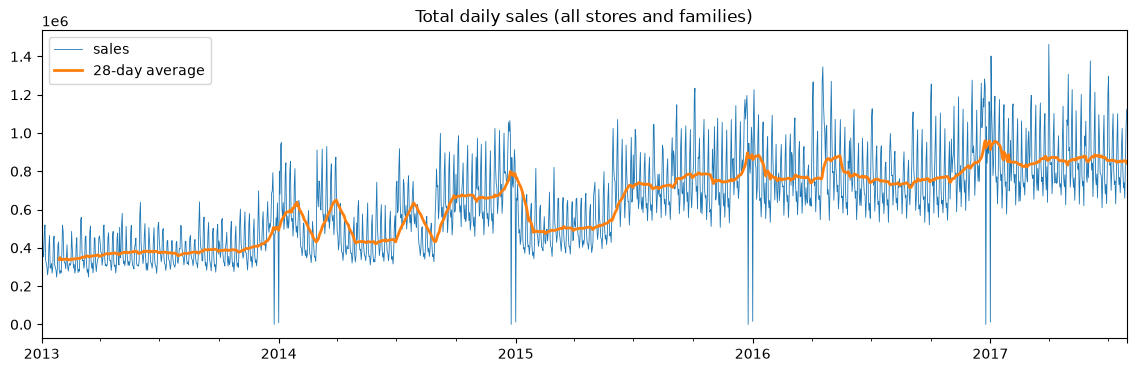

In [5]:
total = fit.groupby("date").sales.sum()
total = total.reindex(pd.date_range(total.index.min(), total.index.max()), fill_value=0)

ax = total.plot(figsize=(14, 4), lw=0.6, title="Total daily sales (all stores and families)")
total.rolling(28).mean().plot(ax=ax, lw=2, label="28-day average")
ax.legend(); plt.show()

What to look for: an upward **trend**, regular wiggles (**weekly pattern**), dips to 0 on **1 January and 25 December**, and anomalies such as the **April 2016 earthquake**.

### Weekly pattern: average sales by day of week

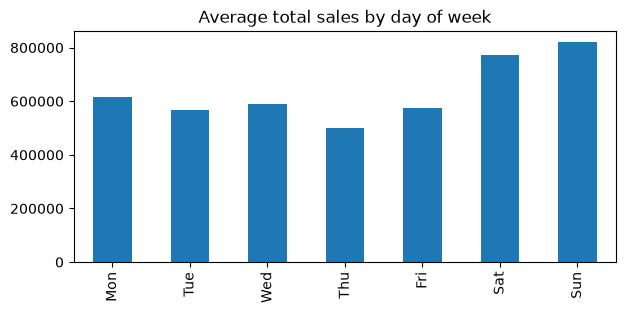

In [6]:
dow = total.groupby(total.index.dayofweek).mean()
dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow.plot.bar(figsize=(7, 3), title="Average total sales by day of week"); plt.show()

### Decomposition and strength scores

Splits the series into **trend + weekly seasonality + leftover noise**, then scores each from 0 to 1
(Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*). Last 2 years only, so the plot is readable.

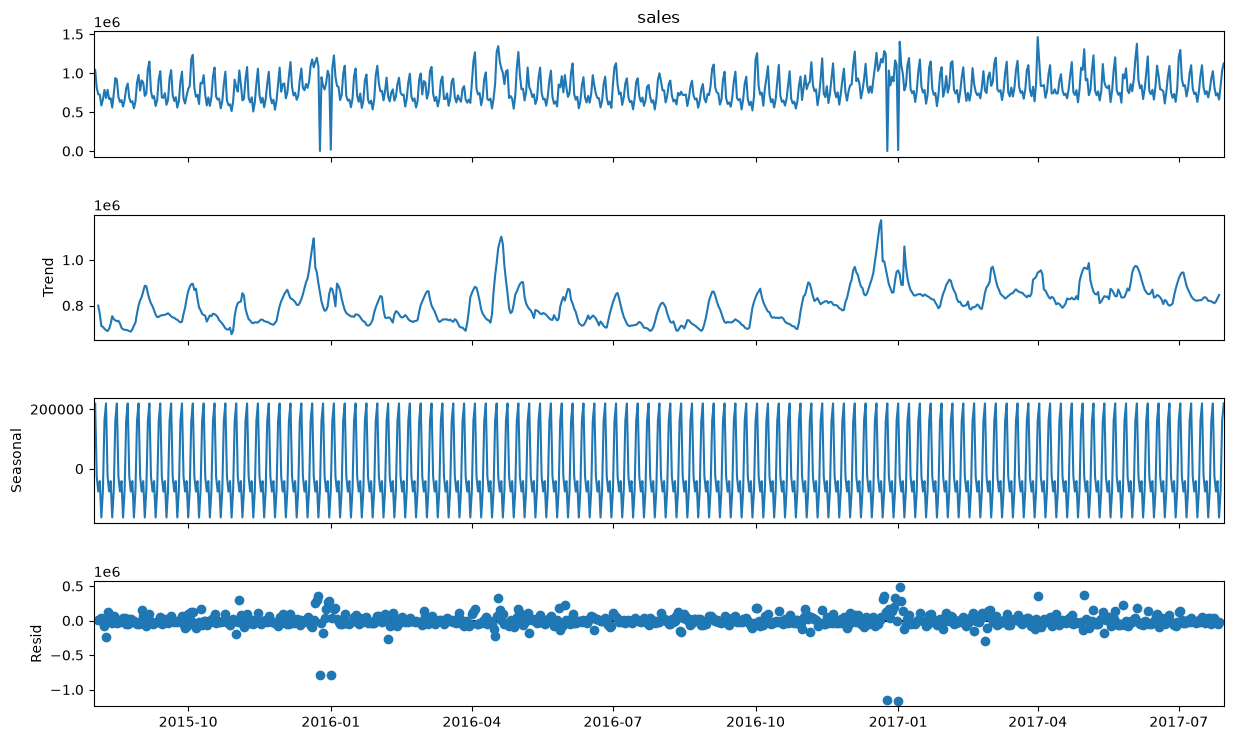

Trend strength:  38.0%
Weekly strength: 58.7%


In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

dec = seasonal_decompose(total[-730:], model="additive", period=7)
dec.plot().set_size_inches(14, 8); plt.show()

resid = dec.resid.dropna()
idx = resid.index
trend_strength = max(0, 1 - resid.var() / (dec.trend[idx] + resid).var())
weekly_strength = max(0, 1 - resid.var() / (dec.seasonal[idx] + resid).var())
print(f"Trend strength:  {trend_strength:.1%}")
print(f"Weekly strength: {weekly_strength:.1%}")

### ACF: how similar is today to k days ago?

Bars outside the shaded band are real patterns. Spikes at **7, 14, 21, 28** mean a weekly pattern,
so LightGBM should get lag features at those distances (at least 16 days back, because we forecast 16 days ahead).

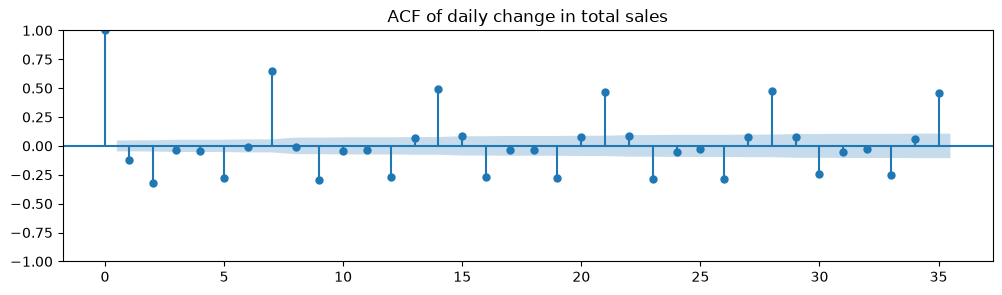

In [8]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 3))
plot_acf(total.diff().dropna(), lags=35, ax=ax)  # .diff() removes the trend so the weekly spikes stand out
ax.set_title("ACF of daily change in total sales"); plt.show()

### Zero-sales series

Some store × family series never sell (e.g. a product a store doesn't stock). For those, the best forecast is simply 0.

series with zero sales in the last 8 weeks: 99 of 1782


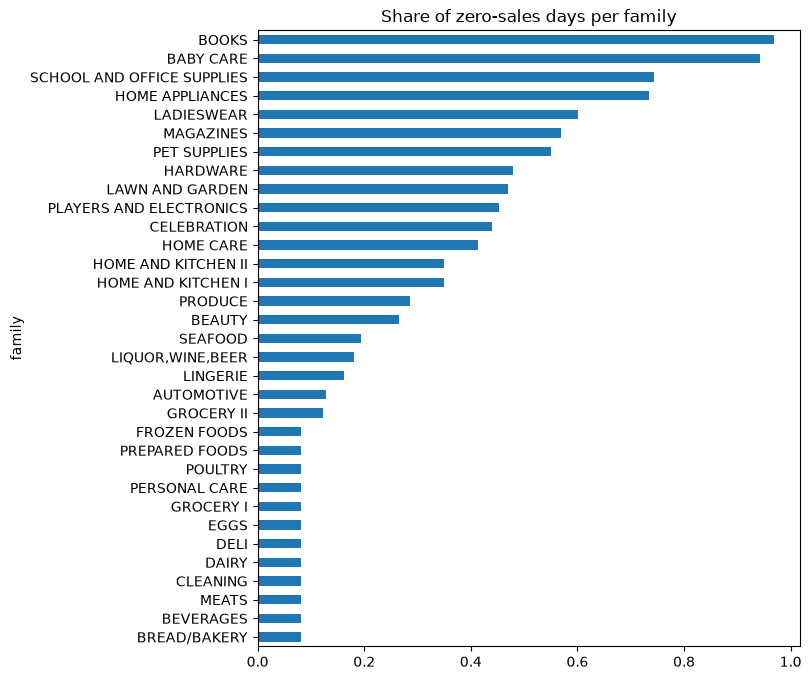

In [9]:
recent = fit[fit.date >= fit.date.max() - pd.Timedelta(days=55)]
dead = recent.groupby(["store_nbr", "family"]).sales.sum().eq(0)
print(f"series with zero sales in the last 8 weeks: {dead.sum()} of {len(dead)}")
(fit.groupby("family").sales.apply(lambda s: (s == 0).mean())
    .sort_values().plot.barh(figsize=(7, 8), title="Share of zero-sales days per family"))
plt.show()

## Step 2: Baselines

Simple rules, no learning. Any real model must beat these.

- **Last week repeated**: Monday = last Monday, Tuesday = last Tuesday, and so on.
- **4-week weekday average**: Monday = average of the last 4 Mondays. Steadier, and our main baseline.

**Backtesting:** one 16-day test could be lucky or unlucky, so every model is scored on **3 back-to-back 16-day windows**.
For each window the model only sees data *before* it. The `mean` row is the number we compare models on.

In [10]:
pd.DataFrame({
    "Last week repeated": backtest(train, lambda fit, valid: baseline(fit, valid, weeks=1)),
    "4-week weekday average": backtest(train, baseline),
}).round(4)

,Last week repeated,4-week weekday average
29 Jun to 14 Jul 2017,0.5176,0.4245
15 Jul to 30 Jul 2017,0.5212,0.4427
31 Jul to 15 Aug 2017,0.6170,0.5311
mean,0.5519,0.4661


Keep the **4-week weekday average mean**: it's the number ARIMA, Prophet and LightGBM must beat.

**Next:** `compare_models.ipynb` runs ARIMA, Prophet and LightGBM (plus their Spark versions) on these same 3 windows.